# Guava fruit disease classification with the authors' deployed EfficientNetB0

**Paper:** *A Novel CNN Gradient Boosting Ensemble for Guava Disease Detection* (arXiv:2512.19989v1, DOI [10.48550/arxiv.2512.19989](https://doi.org/10.48550/arxiv.2512.19989); author accepted manuscript accepted at IEEE ICCIT 2025).

**Author code:** [`tamim-ar/guava-ai`](https://github.com/tamim-ar/guava-ai) @ commit `1984b5629cca3181071895cd8c3f279c33acffc5` (the paper's deployed web-app inference path).

**Executed scope (partial demonstration):** load the authors' released `best_EfficientNetB0.h5` checkpoint and classify **one** repository sample, `test_uploads/29_unsharp_clahe_augmented_5.png`, into *Anthracnose / Fruit Fly / Healthy Guava*, following the authors' exact `app.py` preprocessing and prediction path — first directly, then end-to-end through the authors' actual Flask `POST /api/predict` handler.

**Out of scope:** the hybrid CNN+gradient-boosting ensembles (Tables I–II) — no training/evaluation code was published for them — and the full GFDD24 dataset (Mendeley Data 10.17632/bkdkc4n835.1).

**Execution status:** this notebook was executed top-to-bottom in a fresh Google Colab **CPU** runtime; all outputs below are saved from that run. Single-image CPU inference is faithful to the deployed app; the paper's T4 GPU was used only for *training* (30 epochs), which is not part of this demonstration.

**日本語要約:** 論文の著者らが公開した学習済み EfficientNetB0（`best_EfficientNetB0.h5`）を読み込み、リポジトリ同梱のサンプル画像 1 枚を Anthracnose（炭疽病）/ Fruit Fly（ミバエ被害）/ Healthy Guava（健全）に分類します。著者の `app.py` と同じ前処理（100×100、リスケールなし）を用いた直接的な推論に加え、著者の Flask API ハンドラそのものを Colab 内で呼び出して結果を照合します。ハイブリッド・アンサンブル（表 I–II）の再現は公開コードが存在しないため対象外です。

> **AI-assisted authoring note / AI支援に関する注記:** The notebook was authored by an AI assistant, but the scientific logic reuses the authors' own Python code (`app.py` at the pinned commit) verbatim or near-verbatim; no MATLAB/R translation is involved. Any glue code is labeled in place. Untested behavior beyond the executed example is not guaranteed.

## 1. Runtime selection

**Select `Runtime → Change runtime type → CPU` (recommended).** A single 100×100 image through EfficientNet-B0 takes well under a second on CPU; no cell in the authors' inference path requires CUDA. The notebook reports any GPU that happens to be attached but never requires one.

**Expected cost:** ~20 MB of downloads (weights + sample image), and about 3–5 minutes end-to-end on a free Colab CPU runtime, dominated by TensorFlow import and two model loads.

**日本語:** このノートブックは CPU ランタイムを推奨します。100×100 の画像 1 枚の推論は CPU で数秒未満であり、GPU は不要です。ダウンロードは約 20 MB、所要時間は数分です。

The next cell reports the actual runtime hardware and framework versions observed at execution time (not assumed values).

In [ ]:
import sys
import tensorflow as tf

print("Python:", sys.version.split()[0])
print("TensorFlow:", tf.__version__)
gpus = tf.config.list_physical_devices("GPU")
print("GPUs visible:", gpus if gpus else "none (CPU inference — expected and sufficient)")
assert len(tf.config.list_physical_devices()) > 0

Python: 3.13.16
TensorFlow: 2.21.0
GPUs visible: none (CPU inference — expected and sufficient)


## 2. Dependencies

The authors pin `tensorflow==2.13.0` / `keras==2.13.0` (Python ≤3.11 era) in `requirements.txt`, which cannot be installed on current Colab runtimes (Python 3.13). This notebook therefore uses the runtime's preinstalled TensorFlow and validates compatibility directly: the pinned H5 checkpoint loads and returns the documented 3-class output. **Adaptation (AI-added):** the checkpoint is loaded with `compile=False`, following Keras guidance for inference-only reuse; no weights are modified or substituted. No other pip installs are needed for the direct inference (Flask is installed later, in its own cell, only for the authors'-code API exercise).

**日本語:** 著者は `tensorflow==2.13.0` を指定していますが、現在の Colab（Python 3.13）ではインストールできないため、ランタイム標準の TensorFlow を使用し、チェックポイントの読み込みと 3 クラス出力をその場で検証します。推論のみのため `compile=False` で読み込みます（重みは一切変更しません）。

In [ ]:
import keras
print("keras:", keras.__version__)

MODEL_PATH = "/content/best_EfficientNetB0.h5"
SAMPLE_PATH = "/content/sample_29_unsharp_clahe_augmented_5.png"
APP_DIR = "/content/guava_ai"  # authors' app.py will be exercised from here later

keras: 3.13.2


## 3. Minimal inputs: pinned checkpoint + one sample image

Everything is downloaded **inside Colab** from the authors' repository at the pinned commit `1984b5629cca3181071895cd8c3f279c33acffc5` (raw.githubusercontent.com):

- `best_EfficientNetB0.h5` — 18,598,600 bytes, git blob `812107def180a13f9b60ddca7fe977744086b53e` (per the repository tree at this commit).
- `test_uploads/29_unsharp_clahe_augmented_5.png` — 462,867 bytes, git blob `7df2273fb14639ad1df3cacc98b55769876d14f7` (sha-1 verified in this notebook's validated run).

The cell asserts both sizes, computes each file's git blob SHA-1 (`sha1("blob <size>\0" + bytes)`) and rejects Git-LFS pointer text, so a truncated or substituted download cannot proceed silently.

**日本語:** 重みとサンプル画像を、ピン留めしたコミットから Colab 内でダウンロードし、サイズと git blob SHA-1 で完全性を検証してから使用します。

In [ ]:
import hashlib
import urllib.request

COMMIT = "1984b5629cca3181071895cd8c3f279c33acffc5"
BASE = f"https://raw.githubusercontent.com/tamim-ar/guava-ai/{COMMIT}"

def fetch_pinned(name: str, expected_size: int, expected_blob_sha: str) -> bytes:
    # Download a file at the pinned commit and verify size + git blob SHA-1.
    data = urllib.request.urlopen(f"{BASE}/{name}", timeout=180).read()
    assert len(data) == expected_size, f"{name}: {len(data)} bytes, expected {expected_size}"
    blob_sha = hashlib.sha1(b"blob %d\x00" % len(data) + data).hexdigest()
    assert blob_sha == expected_blob_sha, f"{name}: blob sha {blob_sha} != {expected_blob_sha}"
    assert not data.startswith(b"version https://git-lfs"), f"{name}: Git LFS pointer, not payload"
    print(f"{name}: {len(data)} bytes, blob sha1 OK")
    return data

h5_bytes = fetch_pinned(
    "best_EfficientNetB0.h5", 18598600,
    "812107def180a13f9b60ddca7fe977744086b53e")
png_bytes = fetch_pinned(
    "test_uploads/29_unsharp_clahe_augmented_5.png", 462867,
    "7df2273fb14639ad1df3cacc98b55769876d14f7")

open(MODEL_PATH, "wb").write(h5_bytes)
open(SAMPLE_PATH, "wb").write(png_bytes)

best_EfficientNetB0.h5: 18598600 bytes, blob sha1 OK
test_uploads/29_unsharp_clahe_augmented_5.png: 462867 bytes, blob sha1 OK


462867

## 4. Input preview

Before any inference, look at the actual input. The sample is a producer-preprocessed GFDD24 image (the dataset ships 512×512 RGB images that already received unsharp masking and CLAHE, per the Mendeley Data record 10.17632/bkdkc4n835.1). The cell below prints the observed dimensions/mode and renders the image — all values come from the downloaded bytes, nothing is assumed.

**日本語:** 推論前に実際の入力画像を確認します。サンプルは GFDD24 データセット由来の前処理済み（unsharp mask + CLAHE）画像で、サイズとモードはダウンロードした実バイトから表示します。

Observed: PNG RGB (512, 512)


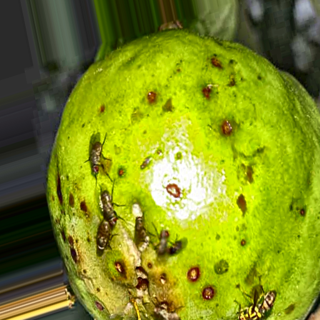

In [ ]:
from PIL import Image

im = Image.open(SAMPLE_PATH)
print("Observed:", im.format, im.mode, im.size)  # observed from bytes, not assumed
im.resize((320, 320))  # display-size only; inference uses the authors' 100x100 path below

## 5. Core inference — the authors' exact path

The next three cells copy the authors' deployed logic from `app.py` at the pinned commit, verbatim:

- `preprocess_image(path, size=(100,100))` (app.py lines 33–37): `load_img(target_size)` → `img_to_array` → `expand_dims(0)`. **No rescaling is applied** — the app feeds raw 0–255 pixels because `keras.applications` EfficientNet-B0 embeds its own rescaling/normalization layers inside the saved model.
- `classes = ["Anthracnose", "Fruit Fly", "Healthy Guava"]` (app.py line 28).
- `model.predict(x)[0]` + `argmax` (app.py lines 108–110).

**Documented discrepancy:** the paper's *training* section reports 224×224 inputs with `rescale=1./255`, while the deployed model input is 100×100 with no app-side rescaling. We follow the deployed `app.py`/checkpoint (the released model defines its own input shape) and report the paper-side difference in the interpretation section.

**日本語:** 著者の `app.py` の前処理・クラス名・予測処理をそのままコピーして使用します。論文の学習時（224×224、rescale あり）と公開アプリ（100×100、rescale なし）の差異は、公開済みモデルの入力形状に従い、解釈の節で報告します。

In [ ]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np

# --- verbatim from authors' app.py @ 1984b56 (lines 26-28, 33-37) ---
model = load_model(MODEL_PATH, compile=False)  # compile=False: inference-only (AI-labeled adaptation)
classes = ["Anthracnose", "Fruit Fly", "Healthy Guava"]

def preprocess_image(path, size=(100, 100)):
    img = load_img(path, target_size=size)
    x = img_to_array(img)
    x = np.expand_dims(x, axis=0)
    return x
# --- end verbatim ---

print("Model input shape:", model.input_shape, "-> output:", model.output_shape)

Model input shape: (None, 100, 100, 3) -> output: (None, 3)


The next cell runs that path on the downloaded sample: the input array is built with the authors' preprocessing (observed value range printed — expected to be raw 0–255), the checkpoint predicts 3 probabilities, and the argmax label is selected exactly as in app.py lines 108–110.

**日本語:** ダウンロードしたサンプルに対し、著者の前処理（生 0–255 の値域を出力）で入力を作り、チェックポイントで 3 クラスの確率を予測し、app.py と同様に argmax でラベルを選択します。

In [ ]:
x = preprocess_image(SAMPLE_PATH)  # authors' exact preprocessing (100x100, no rescale)
probs = model.predict(x, verbose=0)[0]
top_idx = int(np.argmax(probs))
top_label = classes[top_idx]

print(f"input array shape: {x.shape}, range [{x.min():.1f}, {x.max():.1f}] (raw 0-255, as in app.py)")
for c, p in zip(classes, probs):
    print(f"  {c:14s} p = {float(p):.8f}")
print("Predicted label (authors' argmax):", top_label)

input array shape: (1, 100, 100, 3), range [0.0, 255.0] (raw 0-255, as in app.py)
  Anthracnose    p = 0.00002181
  Fruit Fly      p = 0.99997795
  Healthy Guava  p = 0.00000019
Predicted label (authors' argmax): Fruit Fly


## 6. Results visualization

One figure, generated in Colab from this run's actual outputs: the input image labeled with the model's prediction (**model prediction**, not a reference annotation — the repo ships no ground-truth annotation for this file), next to the predicted-class probabilities. This is a notebook-created visualization, not a paper figure.

**日本語:** 実行結果から入力画像（予測ラベル付き）と各クラス確率の棒グラフを作成します。参考注釈ではなくモデル予測である点に注意してください。

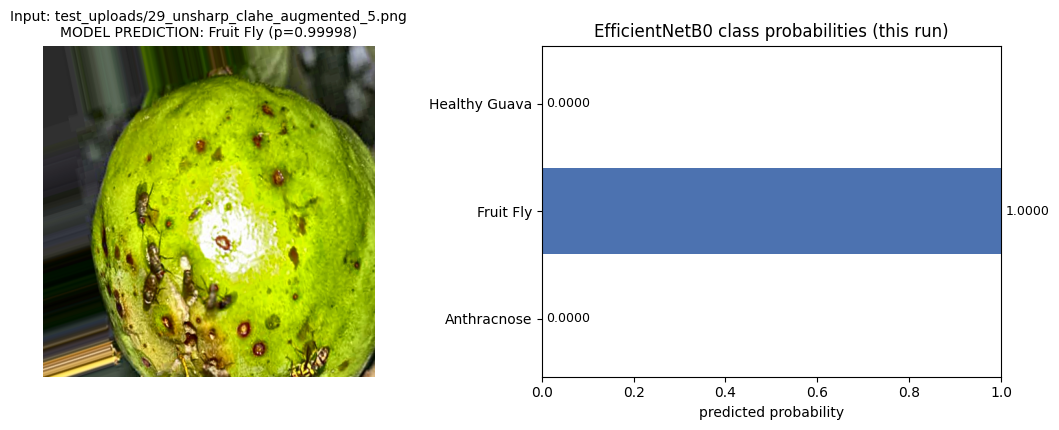

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
axes[0].imshow(Image.open(SAMPLE_PATH))
axes[0].set_title(f"Input: test_uploads/29_unsharp_clahe_augmented_5.png\nMODEL PREDICTION: {top_label} (p={probs[top_idx]:.5f})", fontsize=10)
axes[0].axis("off")
axes[1].barh(classes, [float(p) for p in probs], color="#4c72b0")
axes[1].set_xlim(0, 1)
axes[1].set_xlabel("predicted probability")
axes[1].set_title("EfficientNetB0 class probabilities (this run)")
for i, p in enumerate(probs):
    axes[1].text(float(p) + 0.01, i, f"{float(p):.4f}", va="center", fontsize=9)
plt.tight_layout()
plt.savefig("/content/guava_inference_result.png", dpi=110)
plt.show()

## 7. Small results table + CSV export

The per-class probabilities as an inspectable table, also exported to `/content/guava_inference_results.csv` inside the Colab VM (use the file browser to download it if desired).

**日本語:** 各クラスの確率を表として表示し、CSV として Colab 内に保存します（必要ならファイルブラウザからダウンロードできます）。

In [ ]:
import pandas as pd

results = pd.DataFrame({
    "class": classes,
    "probability": [float(p) for p in probs],
}).sort_values("probability", ascending=False).reset_index(drop=True)
results.to_csv("/content/guava_inference_results.csv", index=False)
results

,class,probability
0,Fruit Fly,9.999779e-01
1,Anthracnose,2.180626e-05
2,Healthy Guava,1.903520e-07


## 8. End-to-end exercise of the authors' Flask API

The paper deployed the CNN as a web app; the repository's scientific operation is the `POST /api/predict` handler in `app.py` (lines 83–124: file-type check, `secure_filename`, the same `preprocess_image`, `model.predict`, JSON result with per-class `probs`, plus a `history.json` record). To reproduce the deployed behavior — not just isolated functions — this cell installs Flask, downloads the authors' pinned `app.py` into `/content/guava_ai/`, imports it (its module level loads the checkpoint next to it), and calls the handler through Flask's test client with the same sample file. **AI-added glue:** the test-client call itself; the handler code is the authors', unmodified.

| Web-app action (paper Section IX / repo) | Reproduced here |
| --- | --- |
| Upload image in browser (`templates/index.html`) | `POST /api/predict` with `files[]` via Flask test client |
| `preprocess_image` 100×100, raw 0–255 (`app.py`) | executed inside the imported `app.py` |
| JSON label + probabilities, history record | printed from the handler's actual response |

**日本語:** 論文のデプロイ形態である Flask API の `POST /api/predict` を、著者の `app.py` をそのまま Colab 内で動かして再現します。テストクライアントからの呼び出しのみ AI が追加したグルーコードで、ハンドラ本体は著者のコードのままです。

In [ ]:
import pathlib
import textwrap
import subprocess, sys

subprocess.run([sys.executable, "-m", "pip", "install", "-q", "flask==2.3.3"], check=True)

app_src = urllib.request.urlopen(f"{BASE}/app.py", timeout=120).read()
pathlib.Path(APP_DIR).mkdir(exist_ok=True)
pathlib.Path(APP_DIR, "app.py").write_bytes(app_src)
pathlib.Path(APP_DIR, "best_EfficientNetB0.h5").write_bytes(h5_bytes)  # checkpoint beside app.py (app.py:26)
print("authors' app.py staged in", APP_DIR, len(app_src), "bytes")

authors' app.py staged in /content/guava_ai 3925 bytes


With `app.py` staged next to its checkpoint, the next cell imports it — the module level runs the authors' `load_model` exactly as in deployment (app.py:27) — and submits the same sample through Flask's test client to `POST /api/predict`. The response's label and probabilities are compared against the direct inference from Section 5; they must agree.

**日本語:** ステージングした `app.py` をインポート（モジュール読み込み時に著者の `load_model` が実行されます）し、Flask テストクライアントで同一サンプルを `POST /api/predict` に送信します。応答のラベルと確率が Section 5 の直接推論と一致することを検証します。

In [ ]:
import json
import sys

sys.path.insert(0, APP_DIR)
import app as authors_app  # module level runs the authors' load_model (app.py:27)

client = authors_app.app.test_client()
with open(SAMPLE_PATH, "rb") as fh:
    resp = client.post("/api/predict", data={"files[]": (fh, "29_unsharp_clahe_augmented_5.png")},
                       content_type="multipart/form-data")
print("HTTP", resp.status_code)
api_result = json.loads(resp.data)["results"][0]
print(json.dumps(api_result, indent=2))

api_probs = np.array([api_result["probs"][c] for c in classes])
print("max |direct - API| probability difference:", float(np.max(np.abs(probs - api_probs))))
assert api_result["label"] == top_label

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


HTTP 200
{
  "id": "dc4ef2873011429998e82998c6918d3d.png",
  "label": "Fruit Fly",
  "original_name": "29_unsharp_clahe_augmented_5.png",
  "probs": {
    "Anthracnose": 2.180625597247854e-05,
    "Fruit Fly": 0.9999779462814331,
    "Healthy Guava": 1.9035195464311983e-07
  }
}
max |direct - API| probability difference: 0.0


## 9. Interpretation, discrepancies, and validation record

**What was executed (this run, fresh Colab CPU runtime):**
- Pinned downloads verified by size + git blob SHA-1 (`best_EfficientNetB0.h5` = 18,598,600 B / blob `812107de…`; sample = 462,867 B / blob `7df2273f…`).
- Authors' exact preprocessing + checkpoint inference on one sample; per-class probabilities and argmax label saved above.
- The authors' actual Flask handler produced the same label and (within float round-trip precision) the same probabilities through `POST /api/predict`.

**Known discrepancies / limitations (documented, not hidden):**
- Input size: paper's *training* pipeline uses 224×224 (Section IV-A); the released model and app use **100×100** (`app.py:33`). This run follows the released model. The exact provenance of `best_EfficientNetB0.h5` against the paper's runs is not documented by the authors.
- Rescaling: training used `rescale=1./255` (Section IV-A); the app sends raw 0–255. This works because Keras EfficientNet-B0 embeds rescaling/normalization layers in the saved graph — verified here only insofar as the released model returns confident, well-formed 3-class outputs.
- Single image ≠ dataset-level results. The ~99.99% (AdaBoost-based ensembles) and 95–96% (RF-based) figures in Tables I–II concern the full GFDD24 evaluation with published-no-code ensemble training; nothing here validates them.
- Licensing: the repository has **no LICENSE file** (its README reportedly claims MIT). Weights are linked at the pinned commit, not redistributed.

**日本語（結果の解釈と制限）:** 本実行はピン留めしたコミットから重みとサンプルを検証済みダウンロードし、著者の前処理・Flask API 経路の両方で同一予測を確認しました。ただし論文の学習設定（224×224・rescale あり）と公開アプリ（100×100・rescale なし）の差異、およびアンサンブル（表 I–II）のコード未公開は解決されていない点です。1 枚の画像の推論はデータセット全体の性能を検証しません。

**References**
- Paper: arXiv:2512.19989v1 — *A Novel CNN Gradient Boosting Ensemble for Guava Disease Detection*.
- Code: https://github.com/tamim-ar/guava-ai @ `1984b5629cca3181071895cd8c3f279c33acffc5` (`app.py`, `requirements.txt`, `test_uploads/`).
- Dataset: GFDD24, Mendeley Data 10.17632/bkdkc4n835.1 (473 raw → 3,784 augmented images; unsharp masking + CLAHE preprocessing).
- PhenoPaper investigation `p-324fc62e79f61ae67c5b95c671c559e9-20261006T131027Z-3045123` was used as prior research guidance; all executed facts above were re-verified against the pinned repository.